In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. تحديد عدد مرات التشغيل العشوائي لمونت كارلو
N_simulations = 10000

# 2. توليد المتغيرات الجيولوجية كالتوزيع الطبيعي والموحد بناءً على قراءات الآبار
# المساحة بالملف (Area in acres) - توزيع موحد بين 4000 و 6000
Area = np.random.uniform(4000, 6000, N_simulations)

# صافي السماكة بالقدم (Net Pay Thickness in feet) - توزيع طبيعي بمتوسط 50 وانحراف معياري 10
Thickness = np.random.normal(50, 10, N_simulations)

# المسامية (Porosity) - توزيع طبيعي بمتوسط 18% وانحراف معياري 3%
Porosity = np.random.normal(0.18, 0.03, N_simulations)

# تشبع النفط (Oil Saturation = 1 - Sw) - توزيع موحد بين 65% و 80%
So = np.random.uniform(0.65, 0.80, N_simulations)

# عامل حجم التشكيل للنفط (Bo) - ثابت تقريباً حول 1.2
Bo = 1.2

# 3. حساب معادلة الـ STOIIP بالبراميل لـ 10 آلاف سيناريو مختلف
# المعادلة: STOIIP = (7758 * Area * Thickness * Porosity * So) / Bo
stoiip_results = (7758 * Area * Thickness * Porosity * So) / Bo / 1e6  # بالمليون برميل (MMbbl)

print("🎲 تم تشغيل محاكاة مونت كارلو 10,000 مرة بنجاح وتوليد سيناريوهات عدم اليقين!")

🎲 تم تشغيل محاكاة مونت كارلو 10,000 مرة بنجاح وتوليد سيناريوهات عدم اليقين!


📋 التقرير الاحتمالي لحجم النفط المتوقع (STOIIP Volumetric Report):
------------------------------------------------------------------
🔹 P90 (الاحتياطي المؤكد - تحفظي): 135.72 مليون برميل.
🔹 P50 (الاحتياطي الكلي المتوقع - واقعي): 204.33 مليون برميل.
🔹 P10 (الاحتياطي الممكن - تفاؤلي): 292.66 مليون برميل.
------------------------------------------------------------------


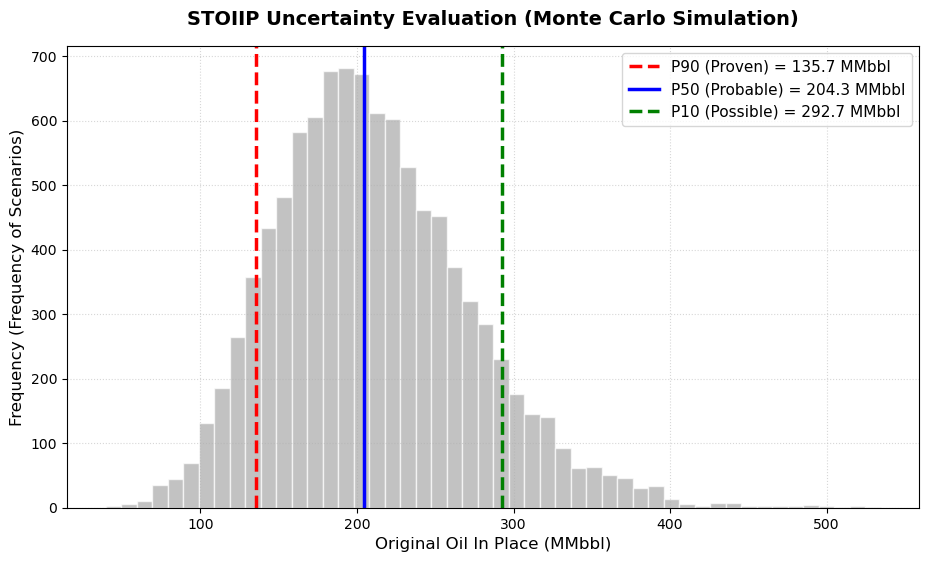

In [2]:
# 1. حساب قيم P10 و P50 و P90 هندسياً باستخدام النسبة المئوية العكسية
p90 = np.percentile(stoiip_results, 10)
p50 = np.percentile(stoiip_results, 50)
p10 = np.percentile(stoiip_results, 90)

# 2. تجهيز لوحة الرسم البياني (التوزيع التكراري - Histogram)
plt.figure(figsize=(11, 6))
counts, bins, patches = plt.hist(stoiip_results, bins=50, color='darkgray', edgecolor='white', alpha=0.7)

# 3. تلوين مناطق عدم اليقين وإضافة خطوط قيم P الحرجة
plt.axvline(p90, color='red', linestyle='--', linewidth=2.5, label=f'P90 (Proven) = {p90:.1f} MMbbl')
plt.axvline(p50, color='blue', linestyle='-', linewidth=2.5, label=f'P50 (Probable) = {p50:.1f} MMbbl')
plt.axvline(p10, color='green', linestyle='--', linewidth=2.5, label=f'P10 (Possible) = {p10:.1f} MMbbl')

# 4. اللمسات الجمالية الهندسية للوحة التحكم
plt.title('STOIIP Uncertainty Evaluation (Monte Carlo Simulation)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Original Oil In Place (MMbbl)', fontsize=12)
plt.ylabel('Frequency (Frequency of Scenarios)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# 5. طباعة التقرير الرقمي أسفل الرسمة
print("📋 التقرير الاحتمالي لحجم النفط المتوقع (STOIIP Volumetric Report):")
print("------------------------------------------------------------------")
print(f"🔹 P90 (الاحتياطي المؤكد - تحفظي): {p90:.2f} مليون برميل.")
print(f"🔹 P50 (الاحتياطي الكلي المتوقع - واقعي): {p50:.2f} مليون برميل.")
print(f"🔹 P10 (الاحتياطي الممكن - تفاؤلي): {p10:.2f} مليون برميل.")
print("------------------------------------------------------------------")

plt.show()